In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, ConfusionMatrixDisplay
from sklearn.feature_extraction.text import CountVectorizer
from datasets import load_dataset
from preprocessing import *
from metrics import calculate_metrics

C:\Users\BluRay\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
label_idx_to_name = {0: "World",  1: "Sports", 2: "Business", 3: "Sci/Tech"}

In [3]:
# Load the AG News dataset from Hugging Face
dataset = load_dataset("sh0416/ag_news")

# Convert to pandas DataFrames
train_df = dataset['train'].to_pandas()
test_df = dataset['test'].to_pandas()

print(f"Train set shape: {train_df.shape}")
print(f"Test set shape: {test_df.shape}")
print("\nTrain data preview:")
print(train_df.head())

# Split into X (features) and y (labels)
# -1 to convert to 0-based labels
X_train = train_df['description']
y_train = train_df['label'] - 1

X_test = test_df['description']
y_test = test_df['label'] - 1 

print(f"\nX_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")


Train set shape: (120000, 3)
Test set shape: (7600, 3)

Train data preview:
   label                                              title  \
0      3  Wall St. Bears Claw Back Into the Black (Reuters)   
1      3  Carlyle Looks Toward Commercial Aerospace (Reu...   
2      3    Oil and Economy Cloud Stocks' Outlook (Reuters)   
3      3  Iraq Halts Oil Exports from Main Southern Pipe...   
4      3  Oil prices soar to all-time record, posing new...   

                                         description  
0  Reuters - Short-sellers, Wall Street's dwindli...  
1  Reuters - Private investment firm Carlyle Grou...  
2  Reuters - Soaring crude prices plus worries\ab...  
3  Reuters - Authorities have halted oil export\f...  
4  AFP - Tearaway world oil prices, toppling reco...  

X_train shape: (120000,)
y_train shape: (120000,)
X_test shape: (7600,)
y_test shape: (7600,)


In [4]:
X_train_preprocessed = text_normalization(X_train)
X_test_preprocessed = text_normalization(X_test)

In [5]:
# Initialize CountVectorizer for binary bigram representation
bigram_vectorizer = CountVectorizer(
    ngram_range=(2, 2),  # Only bigrams (2-word sequences)
    binary=True,         # Binary representation (1 if present, 0 otherwise)
    token_pattern=r'\b\w+\b'  # Tokenize by word boundaries
)

# Fit on training data and transform both train and test
X_train_bigram = bigram_vectorizer.fit_transform(X_train_preprocessed)
X_test_bigram = bigram_vectorizer.transform(X_test_preprocessed)

print(f"Vocabulary size (unique bigrams): {len(bigram_vectorizer.vocabulary_)}")
print(f"X_train_bigram shape: {X_train_bigram.shape}")
print(f"X_test_bigram shape: {X_test_bigram.shape}")
print(f"Data type: {type(X_train_bigram)}")  # Sparse matrix for memory efficiency

# Show some example bigrams
print(f"\nFirst 10 bigrams in vocabulary:")
bigrams = list(bigram_vectorizer.vocabulary_.keys())[:10]
print(bigrams)

Vocabulary size (unique bigrams): 905473
X_train_bigram shape: (120000, 905473)
X_test_bigram shape: (7600, 905473)
Data type: <class 'scipy.sparse._csr.csr_matrix'>

First 10 bigrams in vocabulary:
['reuters short', 'short sellers', 'sellers wall', 'wall street', 'street s', 's dwindling', 'dwindling band', 'band of', 'of ultra', 'ultra cynics']


In [6]:
# decode the first row in X_train_bigram to see which bigrams are present
first_row_bigram = X_train_bigram[0].toarray()[0]
present_bigrams = [bigram for bigram, idx in bigram_vectorizer.vocabulary_.items() if first_row_bigram[idx] == 1]
print(f"\nBigrams present in the first training example:")
print(present_bigrams)
print(f"\nFirst training example (preprocessed): \n{X_train[0]}")


Bigrams present in the first training example:
['reuters short', 'short sellers', 'sellers wall', 'wall street', 'street s', 's dwindling', 'dwindling band', 'band of', 'of ultra', 'ultra cynics', 'cynics are', 'are seeing', 'seeing green', 'green again']

First training example (preprocessed): 
Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again.


### Aggreggating Binary Features for Naive Bayes Classifier
This transforms the data from document-bigram binary features to class-bigram counts, resulting in only 4 rows, one per class.

In [7]:
num_classes = len(label_idx_to_name)
num_features = X_train_bigram.shape[1]

class_bigram_counts = np.zeros((num_classes, num_features), dtype=np.float32)

for label_idx in range(num_classes):
    # Create a boolean mask for the current class
    mask = (y_train.values == label_idx)
    
    # Sum all rows belonging to this class
    class_bigram_counts[label_idx] = X_train_bigram[mask].sum(axis=0).A1

print(f"New matrix data shape: {class_bigram_counts.shape}")

New matrix data shape: (4, 905473)


`.A1` flattens the result into a 1D np array

## Naive Bayes Classifier
### Calculate Class Prior Probabilities
$$P(c) = \frac{\text{Count of documents in class } c}{\text{Total documents in dataset}}$$

In [8]:
total_documents = len(y_train)
class_counts = np.unique(y_train.values, return_counts=True)[1] # [1] gives the counts

log_priors = np.log(class_counts / total_documents)
print(f"Log Priors: {log_priors}")

Log Priors: [-1.38629436 -1.38629436 -1.38629436 -1.38629436]


### Calculate Likelihoods with Laplace Smoothing
$$P(w|c) = \frac{\text{Count of bigram } w \text{ in class } c + 1}{\text{Total bigrams in class } c + \text{Vocabulary size}}$$

Vocabulary size is the total number of unique bigrams, which is also the number of features.

In [9]:
smoothed_numerator = class_bigram_counts + 1 # Add 1 for Laplace smoothing

total_words_per_class = class_bigram_counts.sum(axis=1, keepdims=True)
smoothed_denominator = total_words_per_class + num_features # For each class

log_likelihoods = np.log(smoothed_numerator / smoothed_denominator)

print(f"Smoothed numerator shape: {smoothed_numerator.shape}")
print(f"Smoothed denominator shape: {smoothed_denominator.shape}")
print(f"Log likelihoods shape: {log_likelihoods.shape}")

Smoothed numerator shape: (4, 905473)
Smoothed denominator shape: (4, 1)
Log likelihoods shape: (4, 905473)


`keepdims=True` ensures the shape stays as (4, 1) instead of (4,)

Now that log priors and likelihoods are calculated, the log posterior can be calculated for each class then the class with the highest log posterior can be predicted for each document in the test set.

### Predicting with Naive Bayes

$$\hat{y} = \arg\max_c \left( \log P(c) + \sum_{w} x_w \log P(w|c) \right)$$

Logic: Take the transpose of the likelihood matrix so that the shape is (905473, 4), then the dot product with the test data with shape (N_test, 905473) will give a (N_test, 4) matrix of log posteriors for each class. The highest log posterior can then be found for each document to make the final prediction.

In [10]:
def predict_naive_bayes(X_sparse, log_priors, log_likelihoods):
    # log posterior = log_prior + sum of log likelihoods using dot product
    log_posteriors = X_sparse.dot(log_likelihoods.T)
    log_posteriors += log_priors
    predictions = np.argmax(log_posteriors, axis=1) # axis=1 gets index of max log posterior for each document
    
    return predictions

In [11]:
y_pred = predict_naive_bayes(X_test_bigram, log_priors, log_likelihoods)

## Metrics
### From Scratch Metrics

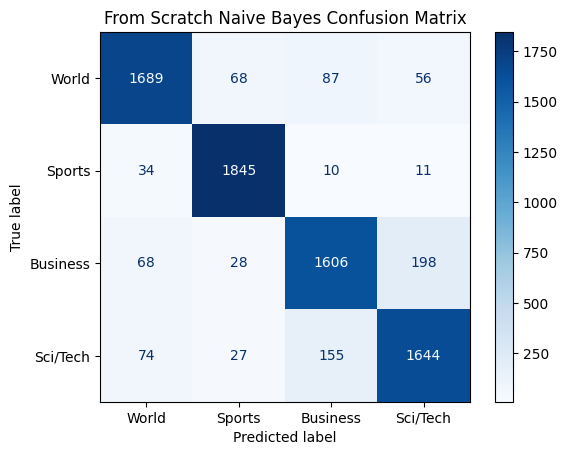

Macro Precision: 0.8922
Macro Recall: 0.8926
Macro F1-Score: 0.8923


In [15]:
cm, precision, recall, f1 = calculate_metrics(y_test.values, y_pred, num_classes)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(label_idx_to_name.values()))
disp.plot(cmap='Blues')
plt.title("From Scratch Naive Bayes Confusion Matrix")
plt.show()

print(f"Macro Precision: {precision:.4f}")
print(f"Macro Recall: {recall:.4f}")
print(f"Macro F1-Score: {f1:.4f}")

### SKLearn Metrics

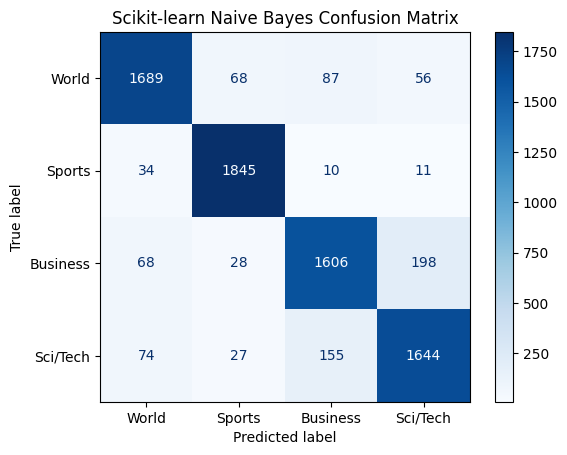

Macro Precision: 0.8922
Macro Recall: 0.8926
Macro F1-Score: 0.8923


In [13]:
sk_cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=sk_cm, display_labels=list(label_idx_to_name.values()))
disp.plot(cmap='Blues')
plt.title("Scikit-learn Naive Bayes Confusion Matrix")
plt.show()

sk_precision = precision_score(y_test, y_pred, average='macro')
sk_recall = recall_score(y_test, y_pred, average='macro')
sk_f1 = f1_score(y_test, y_pred, average='macro')

print(f"Macro Precision: {sk_precision:.4f}")
print(f"Macro Recall: {sk_recall:.4f}")
print(f"Macro F1-Score: {sk_f1:.4f}")

Scikit-learn's metrics are identical to the from scratch metrics.